In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


In [16]:
df = pd.read_csv('encuesta_salud.csv')
print("Valores nulos iniciales por columna:\n", df.isnull().sum())
print("\nDimensiones iniciales:", df.shape)
print("\nEstadísticas de talla_m:\n", df['talla_m'].describe())

Valores nulos iniciales por columna:
 id                   0
edad                45
peso_kg             60
talla_m              0
presion_arterial     0
colesterol          40
glucosa              0
grupo_sanguineo     25
region               0
diagnostico         30
dtype: int64

Dimensiones iniciales: (500, 10)

Estadísticas de talla_m:
 count   500.00
mean      6.76
std      28.92
min       1.33
25%       1.61
50%       1.69
75%       1.75
max     186.00
Name: talla_m, dtype: float64


### Observaciones Iniciales (Ejercicio 1)
- **Dimensiones:** El dataset cuenta con 500 filas y 10 columnas.
- **Tipos de datos:** Variables numéricas para parámetros clínicos y categóricas para datos nominales/ordinales.
- **Valores faltantes:** `edad` (45), `peso_kg` (60), `colesterol` (40), `grupo_sanguineo` (25) y `diagnostico` (30).
- **Anomalías:** En `talla_m`, se observa un valor máximo de 186.0 metros. Esto indica que existen registros ingresados erróneamente en centímetros en lugar de metros.

In [17]:
df.loc[df['talla_m'] > 3, 'talla_m'] = df.loc[df['talla_m'] > 3, 'talla_m'] / 100

df['edad'] = df['edad'].fillna(df['edad'].median())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['colesterol'] = df['colesterol'].fillna(df['colesterol'].median())

df['grupo_sanguineo'] = df['grupo_sanguineo'].fillna(df['grupo_sanguineo'].mode()[0])
df['diagnostico'] = df['diagnostico'].fillna(df['diagnostico'].mode()[0])

### Estrategia de Tratamiento de Valores Faltantes Ejercicio 2
- **Columnas afectadas:** `edad`, `peso_kg`, `colesterol`, `grupo_sanguineo` y `diagnostico`.
- **Estrategia utilizada:** Imputación con `fillna()`. Se utilizó la mediana para numéricos y la moda para categóricos.La `talla_m` se dividió por 100 en los registros mayores a 3 metros (como el de 186.0) para llevarlos a su escala correcta.
- **Justificación:** La mediana es robusta ante outliers. La moda asume el valor más representativo sin perder registros.

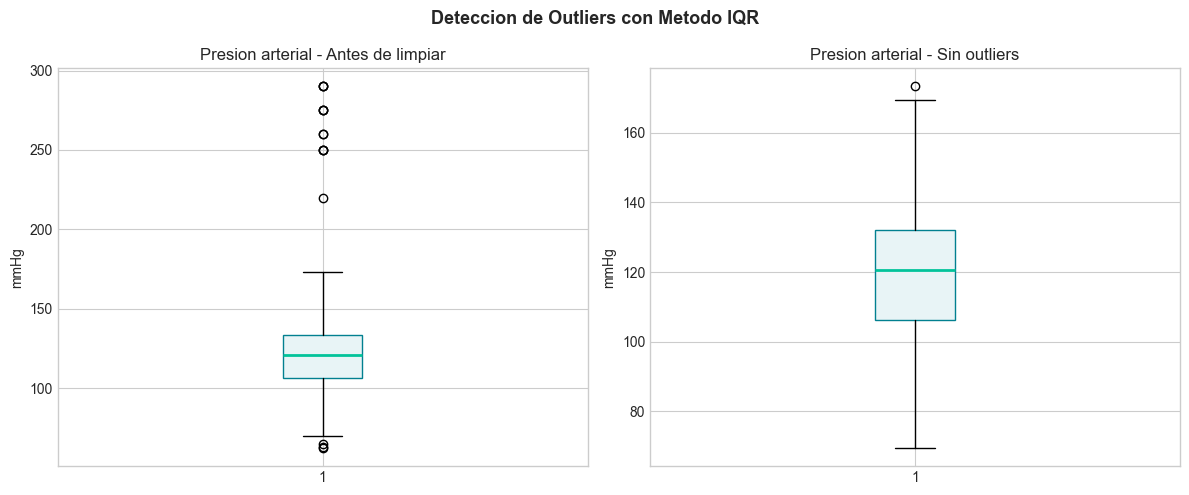

Filas restantes tras eliminar outliers: 475


In [18]:
# 1. IQR para presión arterial
Q1 = df['presion_arterial'].quantile(0.25)
Q3 = df['presion_arterial'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# --- INICIO CÓDIGO DEL GRÁFICO (Corregido del PDF) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Antes de limpiar
axes[0].boxplot(df['presion_arterial'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E8F4F6', color='#028090'),
                medianprops=dict(color='#02C39A', linewidth=2))
axes[0].set_title('Presion arterial - Antes de limpiar')
axes[0].set_ylabel('mmHg')

# Filtrar outliers IQR (creamos df_limpio como pide la guía)
df_limpio = df[(df['presion_arterial'] >= lim_inf) & (df['presion_arterial'] <= lim_sup)]

# Despues de limpiar
axes[1].boxplot(df_limpio['presion_arterial'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#E8F4F6', color='#028090'),
                medianprops=dict(color='#02C39A', linewidth=2))
axes[1].set_title('Presion arterial - Sin outliers')
axes[1].set_ylabel('mmHg')

plt.suptitle('Deteccion de Outliers con Metodo IQR', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_presion.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Z-Score para glucosa (sobre df_limpio)
z_scores = np.abs(stats.zscore(df_limpio['glucosa']))
df_limpio = df_limpio[z_scores < 3]

# Actualizar el DataFrame principal
df = df_limpio.copy()


print("Filas restantes tras eliminar outliers:", len(df))


### Reflexión sobre Outliers Ejercicio 3
**Si los valores extremos de presión representan pacientes reales con hipertensión severa, ¿sería correcto eliminarlos?**

No es correcto eliminarlos. Los datos de hipertensión severa son observaciones clínicas reales, no errores de digitación. Al eliminarlos, estaríamos sesgando el dataset hacia individuos sanos, y los modelos posteriores no podrían identificar a pacientes en riesgo grave. Los outliers solo se deben eliminar cuando existe certeza de que son errores de medición o de ingreso de datos.


In [19]:
scaler = MinMaxScaler()

#Seleccionar las columnas numéricas a normalizar
cols_norm = ['edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa']

#Aplicar Min-Max Scaling
df[cols_norm] = scaler.fit_transform(df[cols_norm])

print("Estadísticas tras Min-Max Scaling (verificar min=0 y max=1):")
print(df[cols_norm].describe().round(3))

Estadísticas tras Min-Max Scaling (verificar min=0 y max=1):
        edad  peso_kg  talla_m  presion_arterial  colesterol  glucosa
count 475.00   475.00   475.00            475.00      475.00   475.00
mean    0.53     0.49     0.54              0.49        0.48     0.58
std     0.28     0.18     0.15              0.18        0.18     0.16
min     0.00     0.00     0.00              0.00        0.00     0.00
25%     0.33     0.40     0.43              0.36        0.37     0.46
50%     0.53     0.49     0.54              0.49        0.49     0.58
75%     0.77     0.61     0.65              0.60        0.59     0.70
max     1.00     1.00     1.00              1.00        1.00     1.00


### Ejercicio 4: Normalización de Variables Numéricas
La normalización es esencial para algoritmos sensibles a la magnitud de las variables. ]En este laboratorio se aplicó la técnica **Min-Max Scaling**

**Técnica seleccionada:** Min-Max Scaling utilizando `MinMaxScaler()` de *scikit-learn*
**Rango resultante:** Los valores fueron transformados al rango cerrado **[0, 1]**
-**Columnas normalizadas:** `edad`, `peso_kg`, `talla_m`, `presion_arterial`, `colesterol` y `glucosa`
**Justificación:** Se utiliza esta técnica para asegurar que todas las variables tengan el mismo peso en análisis posteriores, evitando que aquellas con rangos numéricos más amplios (como el colesterol) dominen sobre las de rangos menores (como la talla en metros)

In [20]:
# 1. Label Encoding para 'diagnostico'
le = LabelEncoder()
df['diagnostico_cod'] = le.fit_transform(df['diagnostico'])
df = df.drop('diagnostico', axis=1)
# 2. One-Hot Encoding para 'region' y 'grupo_sanguineo'
df = pd.get_dummies(df, columns=['region', 'grupo_sanguineo'], drop_first=True)
print("Nuevas dimensiones del DataFrame:", df.shape)

Nuevas dimensiones del DataFrame: (475, 19)


### Codificación de Variables Categóricas Ejercicio 5
- **Variables codificadas:** `diagnostico`, `region`, `grupo_sanguineo`.
- **Estrategia utilizada:** - Se aplicó `LabelEncoder` a la variable `diagnostico` para transformarla en valores numéricos (0, 1, 2...) respetando su contexto clínico.
  - Se aplicó One-Hot Encoding (`pd.get_dummies` con `drop_first=True`) a `region` y `grupo_sanguineo` para binarizar estas categorías nominales sin caer en el problema de la multicolinealidad.

In [21]:
print('='*60)
print('RESUMEN DEL PIPELINE DE LIMPIEZA ENCUESTA SALUD')
print('='*60)
print('Filas originales: 500') 
print(f'Filas finales: {len(df)}')
print('Columnas originales: 10')
print(f'Columnas finales: {len(df.columns)}')
print(f'Valores NaN restantes: {df.isnull().sum().sum()}')
print('\nColumnas del DataFrame final:')
print(list(df.columns))

# Guardar el dataset limpio
df.to_csv('encuesta_salud_limpio.csv', index=False)
print('\nDataset limpio guardado exitosamente como: encuesta_salud_limpio.csv')

RESUMEN DEL PIPELINE DE LIMPIEZA ENCUESTA SALUD
Filas originales: 500
Filas finales: 475
Columnas originales: 10
Columnas finales: 19
Valores NaN restantes: 0

Columnas del DataFrame final:
['id', 'edad', 'peso_kg', 'talla_m', 'presion_arterial', 'colesterol', 'glucosa', 'diagnostico_cod', 'region_Biobio', 'region_Metropolitana', 'region_OHiggins', 'region_Valparaiso', 'grupo_sanguineo_A-', 'grupo_sanguineo_AB+', 'grupo_sanguineo_AB-', 'grupo_sanguineo_B+', 'grupo_sanguineo_B-', 'grupo_sanguineo_O+', 'grupo_sanguineo_O-']

Dataset limpio guardado exitosamente como: encuesta_salud_limpio.csv


## Reporte de Limpieza de Datos

### 1. Valores Faltantes
- **Columnas afectadas:** `edad`, `peso_kg`, `colesterol`, `grupo_sanguineo` y `diagnostico`.
- **Estrategia aplicada:** Imputación de datos reasignando variables (`df[col] = ...`). Se rellenaron los nulos con la mediana para variables numéricas y con la moda para las variables categóricas. La `talla_m` se corrigió dividiendo por 100 los valores atípicos ingresados en centímetros.
- **Justificación:** Se utilizaron la mediana y la moda por ser medidas robustas que no se ven afectadas por valores extremos, conservando la integridad de los datos.

### 2. Outliers
- **Columnas analizadas:** `presion_arterial` y `glucosa`.
- **Método utilizado:** Rango Intercuartílico (`IQR`) para la presión arterial y Método Z-Score (`|z| < 3`) para la glucosa.
- **Observaciones eliminadas:** 25 registros en total.

### 3. Normalización
- **Técnica seleccionada:** `MinMaxScaler`.
- **Justificación:** Se escalaron las variables numéricas al rango `[0, 1]` para evitar que variables con magnitudes muy grandes dominen a otras en algoritmos sensibles a la escala.

### 4. Codificación
- **Variables codificadas:** `diagnostico`, `region`, `grupo_sanguineo`.
- **Método por variable:** - `Label Encoding` para `diagnostico`.
  - `One-Hot Encoding` (con `drop_first=True`) para `region` y `grupo_sanguineo`.
    